# CS4440 Final Project
## Tsunami Prediction using Random Forest

### Members
- Angie Kim
- Edgar Ortiz
- Jason Mar
- Joshua Estrada
- Michael Castillo

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('earthquake_data_tsunami.csv')

print(f"Dataset Shape: {data.shape[0]} rows x {data.shape[1]} columns")

# Convert latitude/longitude (degrees) to 3D Cartesian coordinates (radians)
data['latitude'] = data['latitude'].astype(float)
data['longitude'] = data['longitude'].astype(float)
lat_rad = np.deg2rad(data['latitude'])
lon_rad = np.deg2rad(data['longitude'])
data['X_cart'] = np.cos(lat_rad) * np.cos(lon_rad)
data['Y_cart'] = np.cos(lat_rad) * np.sin(lon_rad)
data['Z_cart'] = np.sin(lat_rad)

# Prepare features and labels (drop original lat/lon if using Cartesian coords)
X = data.drop(['tsunami', 'Year', 'Month', 'latitude', 'longitude'], axis=1)
y = data['tsunami']

# Split the data into training, testing, and validation sets, 80/10/10 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# split the 20% temp into two equal halves -> 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset Shape: 782 rows x 13 columns
Training set size: 625 samples
Validation set size: 78 samples
Testing set size: 79 samples


In [4]:
data.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami,X_cart,Y_cart,Z_cart
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1,-0.923591,0.343554,-0.170146
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0,-0.185622,0.978816,-0.086389
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1,-0.938998,-0.027114,-0.342853
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1,-0.934956,-0.129254,-0.330379
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1,-0.901464,0.027101,-0.432004


**Checking Relative Percentages of minority class:**

In [5]:
print('\nSplit sizes:')
print('Train:', X_train.shape, 'Validation:', X_val.shape, 'Test:', X_test.shape)
print('\nClass counts by split:')
print('Train:\n', y_train.value_counts())
print('Validation:\n', y_val.value_counts())
print('Test:\n', y_test.value_counts())

print('\nPercentages (relative to full dataset):')
print(f"Train%: {len(y_train)/len(data):.4f}")
print(f"Validation%: {len(y_val)/len(data):.4f}")
print(f"Test%: {len(y_test)/len(data):.4f}")



Split sizes:
Train: (625, 11) Validation: (78, 11) Test: (79, 11)

Class counts by split:
Train:
 tsunami
0    382
1    243
Name: count, dtype: int64
Validation:
 tsunami
0    48
1    30
Name: count, dtype: int64
Test:
 tsunami
0    48
1    31
Name: count, dtype: int64

Percentages (relative to full dataset):
Train%: 0.7992
Validation%: 0.0997
Test%: 0.1010


In [ ]:
missing_values = data.isnull().sum().sum()
print(f"Missing Values: {missing_values}")

dupes = data.duplicated().sum()
print(f"Duplicates: {dupes}")

Missing Values: 0
Duplicates: 0


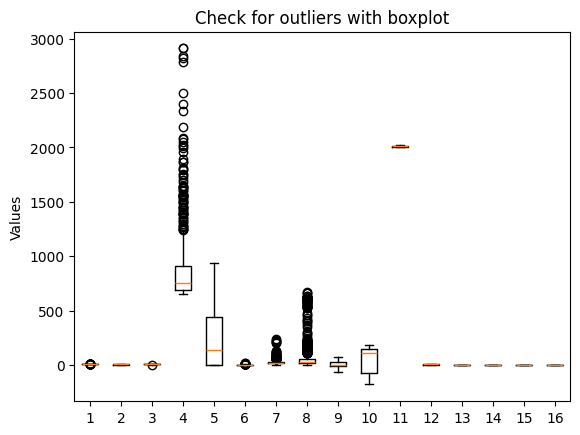

In [12]:
import matplotlib.pyplot as plt
plt.boxplot(data)
plt.title("Check for outliers with boxplot")
plt.ylabel("Values")
plt.show()

### Converting Longitude to Cartesian Coordinates

### Standardizing using Robust Scaler 